In [ ]:
# Business problem
# to know in advance who is gonna subscribe our fixed deposits
# deposit= Target Variables

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [3]:
df=pd.read_excel(r"/content/drive/MyDrive/Teaching/PGA63/ML/DecisionTree/bank.xlsx", sheet_name="bank")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
# EDA ,

# 6- EDA,
# 2- Model development and Validation
# 1- Model deployment
# 1- model monitoring

In [5]:
# Univariate Analysis
# Object, Numerical
ob_col=df.select_dtypes(include="object").columns  # Objective Columns
num_col=df.select_dtypes(include="number").columns # Numerical Columns

In [6]:
ob_col

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

In [7]:
num_col

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [8]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df["job"].value_counts(dropna=False)
# df["job"].nunique()

,count
job,
management,2566
blue-collar,1944
technician,1823
admin.,1334
services,923
retired,778
self-employed,405
student,360
unemployed,357


In [9]:
df["job"]=df["job"].replace(["unemployed", "student", "retired"], "NotEarning")
df["job"]=df["job"].replace(["services", "housemaid"], "Pink_collar")
df["job"]=df["job"].replace(["self-employed", "entrepreneur"], "Employed")

In [10]:
df["job"].value_counts(dropna=False)

,count
job,
management,2566
blue-collar,1944
technician,1823
NotEarning,1495
admin.,1334
Pink_collar,1197
Employed,733
unknown,70


In [11]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['marital'].value_counts(dropna=False)

,count
marital,
married,6351
single,3518
divorced,1293


In [12]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['education'].value_counts(dropna=False)

,count
education,
secondary,5476
tertiary,3689
primary,1500
unknown,497


In [13]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['default'].value_counts(dropna=False)

,count
default,
no,10994
yes,168


In [14]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['housing'].value_counts(dropna=False)

,count
housing,
no,5881
yes,5281


In [15]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['loan'].value_counts(dropna=False)

,count
loan,
no,9702
yes,1460


In [16]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['contact'].value_counts(dropna=False)

,count
contact,
cellular,8042
unknown,2346
telephone,774


In [17]:
ch=pd.crosstab(df["contact"], df["deposit"], margins=True)
ch

deposit,no,yes,All
contact,,,
cellular,3673,4369,8042
telephone,384,390,774
unknown,1816,530,2346
All,5873,5289,11162


In [18]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['month'].value_counts(dropna=False)

,count
month,
may,2824
aug,1519
jul,1514
jun,1222
nov,943
apr,923
feb,776
oct,392
jan,344


In [19]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['poutcome'].value_counts(dropna=False)

,count
poutcome,
unknown,8326
failure,1228
success,1071
other,537


In [20]:
df['poutcome']=df['poutcome'].replace(["unknown"], "other")

In [21]:
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit'
df['deposit'].value_counts(dropna=False)

,count
deposit,
no,5873
yes,5289


In [22]:
# df['deposit']=np.where(df['deposit']=="yes", 1, 0)
df["deposit"]=df["deposit"].map({"yes":1, "no":0})

In [23]:
df['deposit'].value_counts(dropna=False)

,count
deposit,
0,5873
1,5289


In [24]:
num_col

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [25]:
# 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'
df.describe(percentiles=[0.01,.02,.03,.04,.05,.5,.9,.95,.96,.97,.98,.99]).T

,count,mean,std,min,1%,2%,3%,4%,5%,50%,90%,95%,96%,97%,98%,99%,max
age,11162.0,41.231948,11.913369,18.0,22.0,24.0,25.0,25.00,26.00,39.0,58.0,61.00,64.00,68.00,72.00,77.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,-522.0,-367.0,-244.0,-147.36,-54.95,550.0,3897.6,6026.45,6987.48,8090.36,10086.00,13226.98,81204.0
day,11162.0,15.658036,8.420740,1.0,1.0,2.0,2.0,2.00,3.00,15.0,28.0,30.00,30.00,30.00,30.00,31.00,31.0
duration,11162.0,371.993818,347.128386,2.0,14.0,23.0,34.0,44.00,51.00,255.0,838.0,1079.90,1148.00,1236.17,1372.34,1577.17,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,1.0,1.0,1.00,1.00,2.0,5.0,7.00,8.00,8.00,10.00,13.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,-1.0,-1.00,-1.00,-1.0,191.0,326.00,343.00,355.00,369.00,425.39,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,0.0,0.00,0.00,0.0,3.0,5.00,5.00,6.00,7.00,10.00,58.0
deposit,11162.0,0.473840,0.499338,0.0,0.0,0.0,0.0,0.00,0.00,0.0,1.0,1.00,1.00,1.00,1.00,1.00,1.0


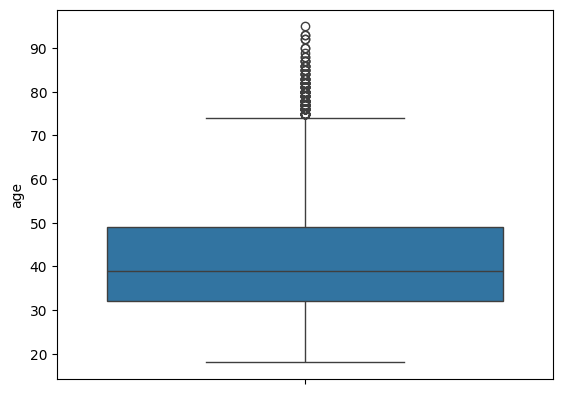

In [26]:
sns.boxplot(df["age"])
plt.show()

In [ ]:
# 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'
df.describe(percentiles=[0.01,.02,.03,.04,.05,.1,.25,.5, .75,.9,.95,.96,.97,.98,.99]).T

,count,mean,std,min,1%,2%,3%,4%,5%,10%,25%,50%,75%,90%,95%,96%,97%,98%,99%,max
age,11162.0,41.231948,11.913369,18.0,22.0,24.0,25.0,25.00,26.00,28.0,32.0,39.0,49.00,58.0,61.00,64.00,68.00,72.00,77.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,-522.0,-367.0,-244.0,-147.36,-54.95,0.0,122.0,550.0,1708.00,3897.6,6026.45,6987.48,8090.36,10086.00,13226.98,81204.0
day,11162.0,15.658036,8.420740,1.0,1.0,2.0,2.0,2.00,3.00,4.0,8.0,15.0,22.00,28.0,30.00,30.00,30.00,30.00,31.00,31.0
duration,11162.0,371.993818,347.128386,2.0,14.0,23.0,34.0,44.00,51.00,77.0,138.0,255.0,496.00,838.0,1079.90,1148.00,1236.17,1372.34,1577.17,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.0,2.0,3.00,5.0,7.00,8.00,8.00,10.00,13.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,20.75,191.0,326.00,343.00,355.00,369.00,425.39,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,1.00,3.0,5.00,5.00,6.00,7.00,10.00,58.0
deposit,11162.0,0.473840,0.499338,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.0


In [27]:
def outlier_capping_method2(data):
  num_col=data.select_dtypes(include="number").columns
  for i in num_col:
    data[i]=data[i].clip(lower=data[i].quantile(0.01), upper=data[i].quantile(0.99))
  return data

In [28]:
df2=outlier_capping_method2(df)

In [29]:
df2.describe(percentiles=[0.01,.02,.03,.04,.05,.1,.25,.5, .75,.9,.95,.96,.97,.98,.99]).T

,count,mean,std,min,1%,2%,3%,4%,5%,10%,25%,50%,75%,90%,95%,96%,97%,98%,99%,max
age,11162.0,41.198172,11.734976,22.0,22.0,24.0,25.0,25.00,26.00,28.0,32.0,39.0,49.00,58.0,61.00,64.00,68.00,72.00,77.0000,77.00
balance,11162.0,1430.772779,2324.020682,-522.0,-522.0,-367.0,-244.0,-147.36,-54.95,0.0,122.0,550.0,1708.00,3897.6,6026.45,6987.48,8090.36,10086.00,13183.6822,13226.98
day,11162.0,15.658036,8.420740,1.0,1.0,2.0,2.0,2.00,3.00,4.0,8.0,15.0,22.00,28.0,30.00,30.00,30.00,30.00,31.0000,31.00
duration,11162.0,368.063433,327.559756,14.0,14.0,23.0,34.0,44.00,51.00,77.0,138.0,255.0,496.00,838.0,1079.90,1148.00,1236.17,1372.34,1576.4563,1577.17
campaign,11162.0,2.433883,2.176754,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.0,2.0,3.00,5.0,7.00,8.00,8.00,10.00,13.0000,13.00
pdays,11162.0,50.111958,103.016608,-1.0,-1.0,-1.0,-1.0,-1.00,-1.00,-1.0,-1.0,-1.0,20.75,191.0,326.00,343.00,355.00,369.00,425.1521,425.39
previous,11162.0,0.776384,1.797315,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,1.00,3.0,5.00,5.00,6.00,7.00,10.0000,10.00
deposit,11162.0,0.473840,0.499338,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,1.00,1.0,1.00,1.00,1.00,1.00,1.0000,1.00


In [ ]:
df2["pdays"].value_counts()

,count
pdays,
-1.00,8324
425.39,112
92.00,106
182.00,89
91.00,84
...,...
373.00,1
247.00,1
61.00,1


In [ ]:
1/2

0.5

In [ ]:
1/100

0.01

In [30]:
df2["pdays"]=np.where(df2["pdays"]==-1, 9999, df2["pdays"])
df2["recent_days"]=1/df2["pdays"]
df2.drop(columns=["pdays"], inplace=True)

In [31]:
df2["recent_days"]

,recent_days
0,0.000100
1,0.000100
2,0.000100
3,0.000100
4,0.000100
...,...
11157,0.000100
11158,0.000100
11159,0.000100
11160,0.005814


In [32]:
df2.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [33]:
ob_col

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

In [44]:
cat_col=df2.select_dtypes(include="object").columns

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
df6=df2.copy()
lb_job=LabelEncoder()
df6["job"]=lb_job.fit_transform(df6["job"])

In [36]:
df6.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous,poutcome,deposit,recent_days
0,59,3,married,secondary,no,2343.0,yes,no,unknown,5,may,1042.0,1,0,other,1,0.0001
1,56,3,married,secondary,no,45.0,no,no,unknown,5,may,1467.0,1,0,other,1,0.0001
2,41,6,married,secondary,no,1270.0,yes,no,unknown,5,may,1389.0,1,0,other,1,0.0001
3,55,2,married,secondary,no,2476.0,yes,no,unknown,5,may,579.0,1,0,other,1,0.0001
4,54,3,married,tertiary,no,184.0,no,no,unknown,5,may,673.0,2,0,other,1,0.0001


In [37]:
lb_job.classes_

array(['Employed', 'NotEarning', 'Pink_collar', 'admin.', 'blue-collar',
       'management', 'technician', 'unknown'], dtype=object)

In [38]:
for i , j in enumerate(lb_job.classes_):
  print(j, ": ", i)

Employed :  0
NotEarning :  1
Pink_collar :  2
admin. :  3
blue-collar :  4
management :  5
technician :  6
unknown :  7


In [39]:
lb_contact=LabelEncoder()
df6["contact"]=lb_contact.fit_transform(df6["contact"])

In [40]:
lb_contact.classes_

array(['cellular', 'telephone', 'unknown'], dtype=object)

In [41]:
for i , j in enumerate(lb_contact.classes_):
  print(j, ": ", i)

cellular :  0
telephone :  1
unknown :  2


In [42]:
df5=df2.copy()

In [45]:
# Convert Non numerical into numerical
# pd.get_dummies(df2, drop_first=True, dtype="int")
# Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact','month', 'poutcome', 'deposit']/,dtype='object'
encoders={}
for i in cat_col:
  encoder=LabelEncoder()
  encoders[i]=encoder
  df5[i]=encoder.fit_transform(df5[i])

In [46]:
encoders

{'job': LabelEncoder(),
 'marital': LabelEncoder(),
 'education': LabelEncoder(),
 'default': LabelEncoder(),
 'housing': LabelEncoder(),
 'loan': LabelEncoder(),
 'contact': LabelEncoder(),
 'month': LabelEncoder(),
 'poutcome': LabelEncoder()}

In [47]:
df5.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous,poutcome,deposit,recent_days
0,59,3,1,1,0,2343.0,1,0,2,5,8,1042.0,1,0,1,1,0.0001
1,56,3,1,1,0,45.0,0,0,2,5,8,1467.0,1,0,1,1,0.0001
2,41,6,1,1,0,1270.0,1,0,2,5,8,1389.0,1,0,1,1,0.0001
3,55,2,1,1,0,2476.0,1,0,2,5,8,579.0,1,0,1,1,0.0001
4,54,3,1,2,0,184.0,0,0,2,5,8,673.0,2,0,1,1,0.0001


In [48]:
encoders["job"].classes_

array(['Employed', 'NotEarning', 'Pink_collar', 'admin.', 'blue-collar',
       'management', 'technician', 'unknown'], dtype=object)

In [49]:
encoders["marital"].classes_

array(['divorced', 'married', 'single'], dtype=object)

In [50]:
encoders['contact'].inverse_transform([2])

array(['unknown'], dtype=object)

In [51]:
for i , j in enumerate(encoders['month'].classes_):
  print(j, ": ", i)

apr :  0
aug :  1
dec :  2
feb :  3
jan :  4
jul :  5
jun :  6
mar :  7
may :  8
nov :  9
oct :  10
sep :  11


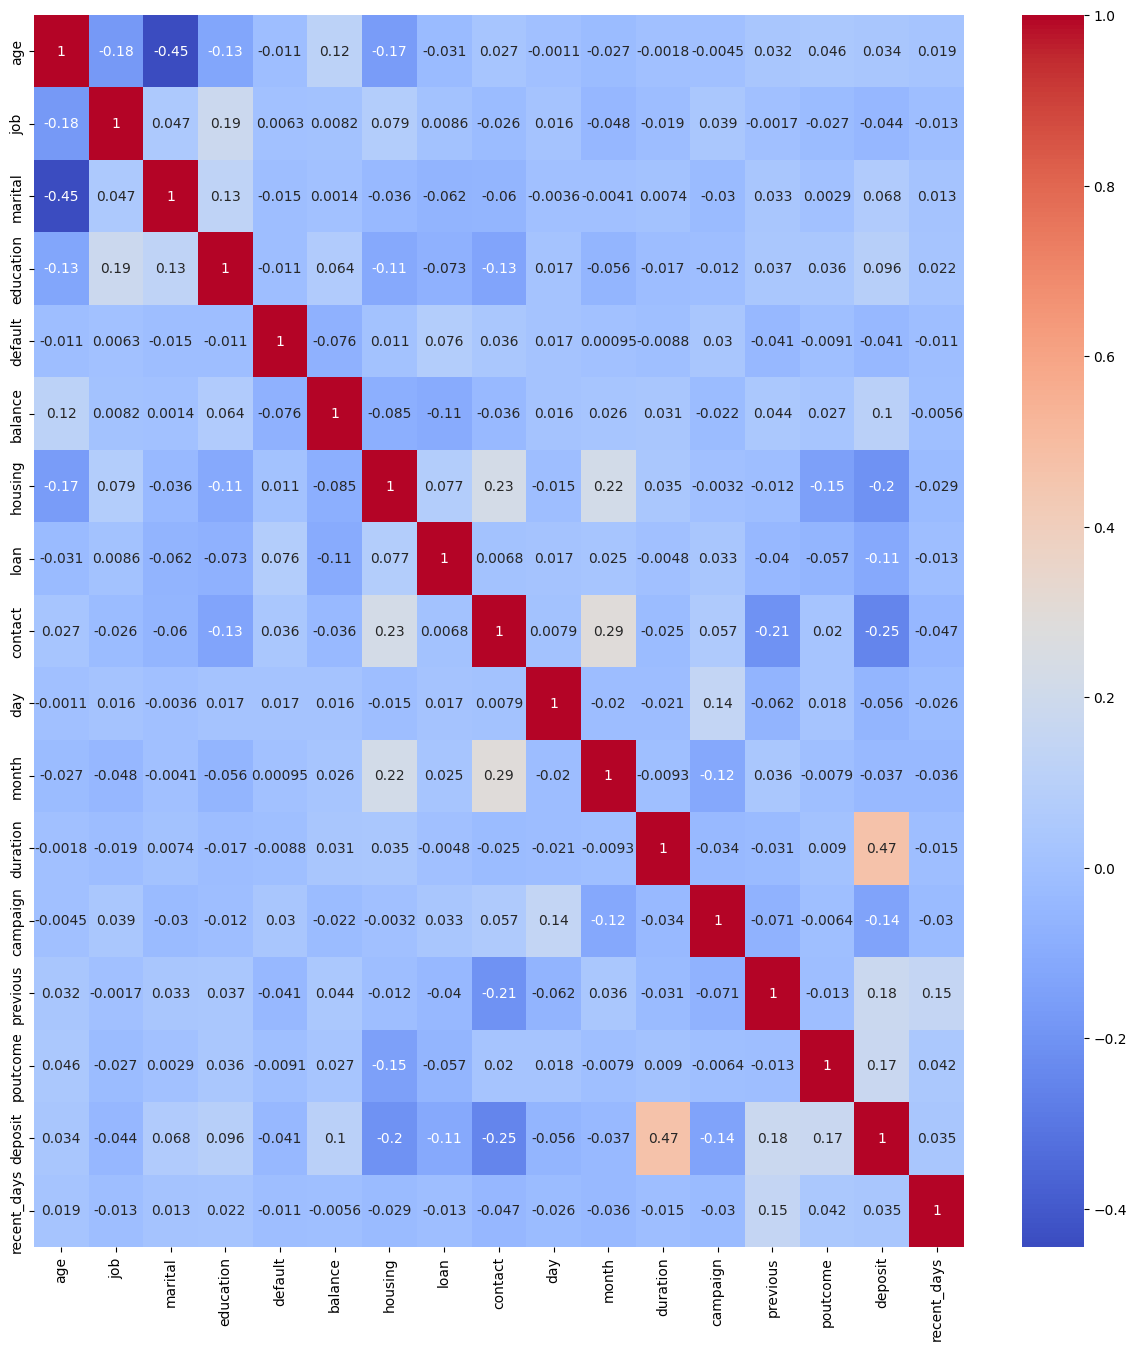

In [52]:
cr=df5.corr()
plt.figure(figsize=(15,16))
sns.heatmap(cr, annot=True, cmap="coolwarm")
plt.show()

In [53]:
df5.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous',
       'poutcome', 'deposit', 'recent_days'],
      dtype='object')

In [ ]:
# step1:  y and x seperate
# step2 : split into x_train, x_test,y_train, y_test
# step3 : create object of logistic Reg and fit on train
# step4 : get score on train and test

In [ ]:
df5.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous',
       'poutcome', 'deposit', 'recent_days'],
      dtype='object')

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          11162 non-null  int64  
 1   job          11162 non-null  int64  
 2   marital      11162 non-null  int64  
 3   education    11162 non-null  int64  
 4   default      11162 non-null  int64  
 5   balance      11162 non-null  float64
 6   housing      11162 non-null  int64  
 7   loan         11162 non-null  int64  
 8   contact      11162 non-null  int64  
 9   day          11162 non-null  int64  
 10  month        11162 non-null  int64  
 11  duration     11162 non-null  float64
 12  campaign     11162 non-null  int64  
 13  previous     11162 non-null  int64  
 14  poutcome     11162 non-null  int64  
 15  deposit      11162 non-null  int64  
 16  recent_days  11162 non-null  float64
dtypes: float64(3), int64(14)
memory usage: 1.4 MB


In [54]:
# Model development
y=df5["deposit"]
x=df5.drop(columns=["deposit"])

In [55]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.25, random_state=0)

In [56]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [57]:
print(lr.score(x_train, y_train))

0.7692032015290885


In [58]:
print(lr.score(x_test, y_test))

0.7624507345037621


In [59]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [60]:
dt_model=DecisionTreeClassifier()  # creating object of Decision Tree model
dt_model.fit(x_train, y_train)

DecisionTreeClassifier()

In [61]:
print("train Score/Accuracy :", dt_model.score(x_train, y_train))
print("test Score/Accuracy : ", dt_model.score(x_test, y_test))

train Score/Accuracy : 1.0
test Score/Accuracy :  0.7696166248656395


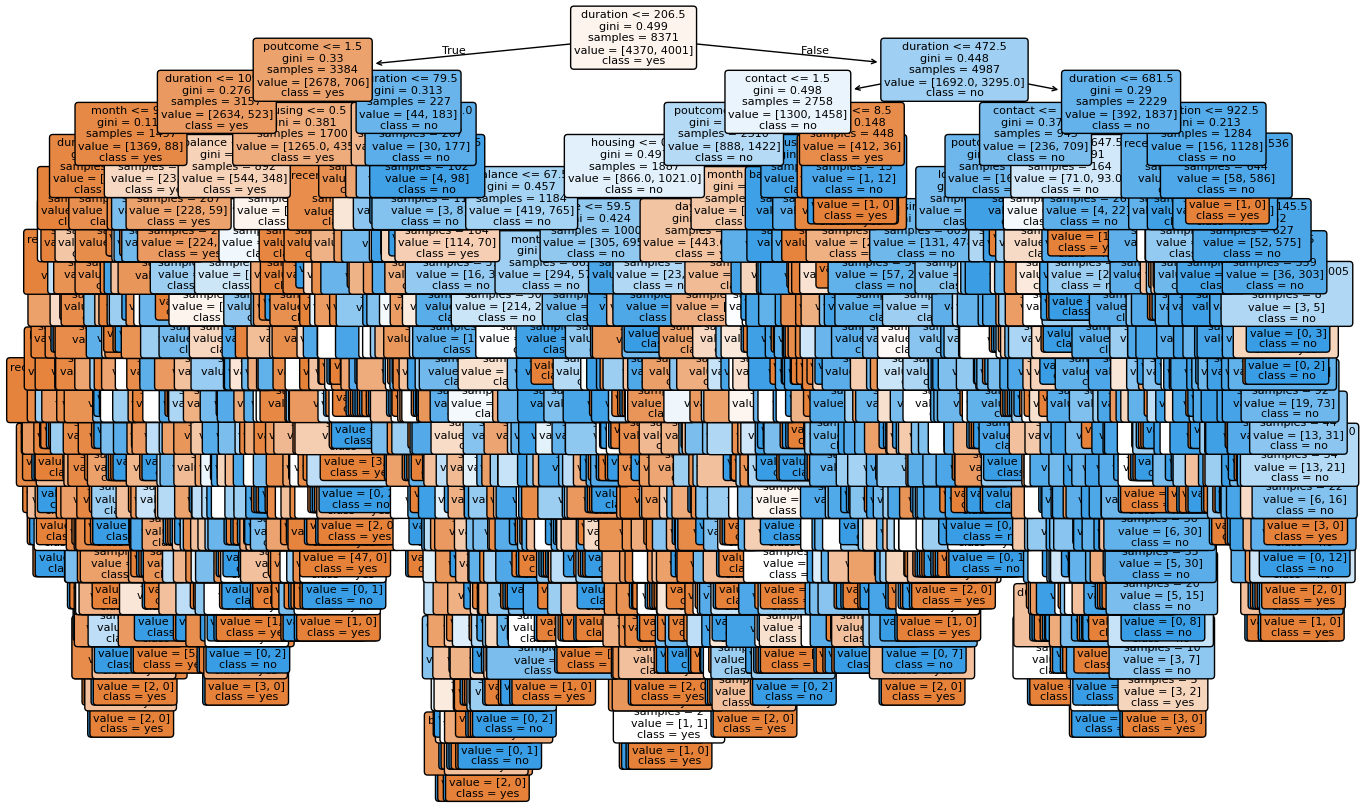

In [62]:
# Plot with larger nodes
plt.figure(figsize=(16, 10))  # Increase figure size
plot_tree(dt_model,
          feature_names=x_train.columns,
          class_names=["yes", "no"] ,
          filled=True,
          rounded=True,
          fontsize=8)  # Increase font size
plt.show()

In [ ]:
# help(DecisionTreeClassifier)

In [63]:

dt_model=DecisionTreeClassifier(criterion="entropy", max_depth=11, min_samples_split=200, min_samples_leaf=100)  # creating object of Decision Tree model
dt_model.fit(x_train, y_train)
print("train Score/Accuracy :", dt_model.score(x_train, y_train))
print("test Score/Accuracy : ", dt_model.score(x_test, y_test))

train Score/Accuracy : 0.8229602198064747
test Score/Accuracy :  0.8000716589036188


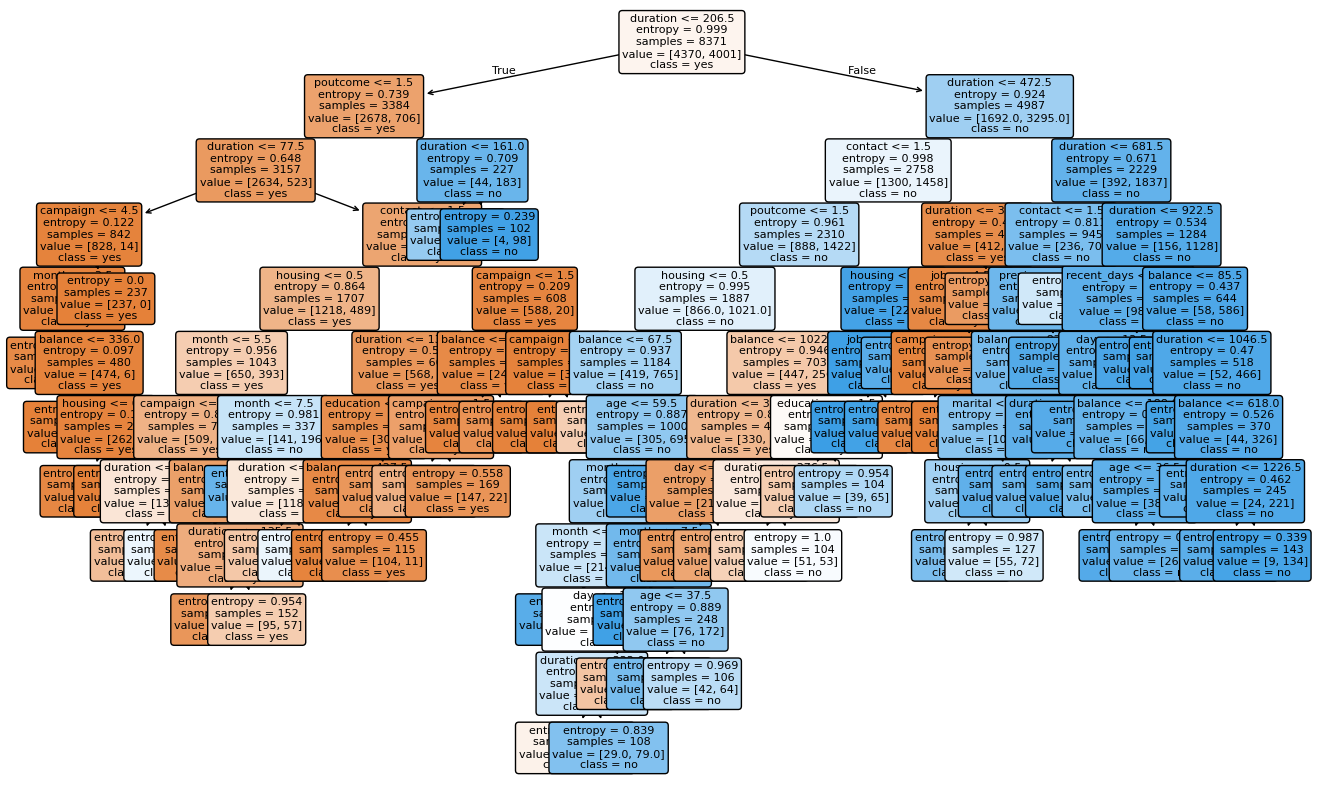

In [64]:
# Plot with larger nodes
plt.figure(figsize=(16, 10))  # Increase figure size
plot_tree(dt_model,
          feature_names=x.columns,
          class_names=["yes", "no"] ,
          filled=True,
          rounded=True,
          fontsize=8)  # Increase font size
plt.show()

In [72]:
# Hyperparameter tuning

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

params={"criterion" : ["gini", "entropy"],
        "max_depth":[4,5,7,8,10,11,12,14, 16,18,20],
        "min_samples_split":[20,50, 70,100, 120, 150, 200, 250, 300],
        "min_samples_leaf":[5,10,15,20,30,40,50, 100, 150]}


dt=DecisionTreeClassifier(random_state=0)

grid=GridSearchCV(dt, param_grid=params, cv=10, scoring="accuracy", verbose=2, n_jobs=-1)
grid.fit(x_train, y_train)


Fitting 10 folds for each of 1782 candidates, totalling 17820 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 7, 8, 10, 11, 12, 14, 16, 18, 20],
                         'min_samples_leaf': [5, 10, 15, 20, 30, 40, 50, 100,
                                              150],
                         'min_samples_split': [20, 50, 70, 100, 120, 150, 200,
                                               250, 300]},
             scoring='accuracy', verbose=2)

In [73]:
len(params['criterion'])*len(params['max_depth'])*len(params['min_samples_split'])*len(params['min_samples_leaf'])*10

17820

In [71]:
# counter=0
# for i in params['criterion']:
#   for j in params['max_depth']:
#     for k in params['min_samples_split']:
#       for l in params['min_samples_leaf']:
#         counter+=1
#         print(f"Iteration ={counter}, Criterion={i}, Max_depth={j}, Min_samples_split={k}, Min_samples_leaf={l}")

In [74]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 16,
 'min_samples_leaf': 10,
 'min_samples_split': 100}

In [75]:
# grid.best_estimator_

In [76]:
grid.best_score_

np.float64(0.8343085174634947)

In [77]:
results=pd.DataFrame(grid.cv_results_)
results.to_csv("grid_results.csv")

In [78]:
final_model=DecisionTreeClassifier(criterion='entropy', max_depth=16, min_samples_leaf=10,
                       min_samples_split=100, random_state=0)

In [79]:
final_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=16, min_samples_leaf=10,
                       min_samples_split=100, random_state=0)

In [80]:
print("Train Score/Acuracy: ", final_model.score(x_train, y_train))
print("Test Score/Acuracy: ", final_model.score(x_test, y_test))

Train Score/Acuracy:  0.8521084697168797
Test Score/Acuracy:  0.8204944464349695


In [ ]:
# Break Time : Come back by 12:50 pm

In [81]:
pred_train=final_model.predict(x_train)
pred_test=final_model.predict(x_test)

In [82]:
pd.DataFrame(metrics.confusion_matrix(y_train, pred_train), columns=["Predicted Negative", "Predicted Positive"], index=["Actual Negative", "Actual Positive"])

,Predicted Negative,Predicted Positive
Actual Negative,3635,735
Actual Positive,503,3498


In [83]:
3498+600

4098

In [84]:
3498+820

4318

In [85]:
4318-4233

85

In [86]:
3498+735

4233

In [87]:
metrics.confusion_matrix(y_test, pred_test)

array([[1210,  293],
       [ 208, 1080]])

In [88]:
print(metrics.classification_report(y_train, pred_train))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4370
           1       0.83      0.87      0.85      4001

    accuracy                           0.85      8371
   macro avg       0.85      0.85      0.85      8371
weighted avg       0.85      0.85      0.85      8371



In [89]:
print(metrics.classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1503
           1       0.79      0.84      0.81      1288

    accuracy                           0.82      2791
   macro avg       0.82      0.82      0.82      2791
weighted avg       0.82      0.82      0.82      2791



In [90]:
final_model.predict_proba(x_train)[:,1]

array([0.78666667, 0.01428571, 0.15584416, ..., 0.        , 0.01538462,
       1.        ])

In [91]:
train_prob=final_model.predict_proba(x_train)[:,1]
test_prob=final_model.predict_proba(x_test)[:,1]


In [100]:
new_pred_train=np.where(train_prob>.25, 1, 0)
new_pred_test=np.where(test_prob>.25, 1, 0)

In [101]:
pd.DataFrame(metrics.confusion_matrix(y_train, new_pred_train), columns=["Predicted Negative", "Predicted Positive"], index=["Actual Negative", "Actual Positive"])

,Predicted Negative,Predicted Positive
Actual Negative,3054,1316
Actual Positive,152,3849


In [102]:
print(metrics.classification_report(y_train, new_pred_train))

              precision    recall  f1-score   support

           0       0.95      0.70      0.81      4370
           1       0.75      0.96      0.84      4001

    accuracy                           0.82      8371
   macro avg       0.85      0.83      0.82      8371
weighted avg       0.85      0.82      0.82      8371



In [103]:
print(metrics.classification_report(y_test, new_pred_test))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1503
           1       0.72      0.93      0.81      1288

    accuracy                           0.80      2791
   macro avg       0.82      0.81      0.80      2791
weighted avg       0.83      0.80      0.80      2791



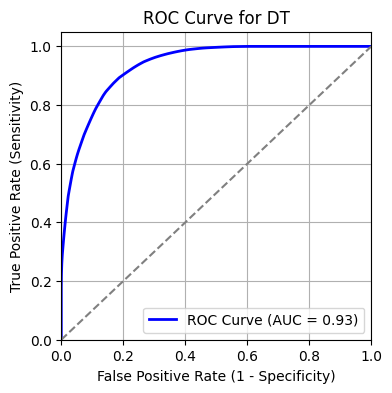

AUC Score: 0.9339


In [104]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_train, train_prob)
roc_auc = auc(fpr, tpr)  # Compute AUC - area under the curve

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random model
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for DT')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Print AUC Score
print(f'AUC Score: {roc_auc:.4f}')


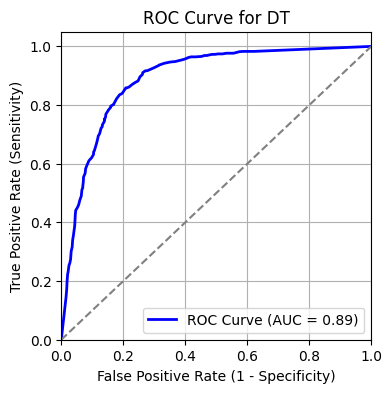

AUC Score: 0.8896


In [105]:
fpr, tpr, thresholds = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)  # Compute AUC - area under the curve

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random model
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for DT')
plt.legend(loc='lower right')
plt.grid()
plt.show()
# Print AUC Score
print(f'AUC Score: {roc_auc:.4f}')


In [106]:
final_model.feature_importances_

array([0.02175687, 0.00694071, 0.0044459 , 0.0049678 , 0.        ,
       0.04125718, 0.04519222, 0.00148519, 0.11781825, 0.02285765,
       0.13212778, 0.4551986 , 0.00855332, 0.00687357, 0.12071421,
       0.00981074])

In [107]:
imp=pd.DataFrame(final_model.feature_importances_,index=x.columns,
                 columns=["Importance"]).sort_values(by="Importance", ascending=False)

In [108]:
imp

,Importance
duration,0.455199
month,0.132128
poutcome,0.120714
contact,0.117818
housing,0.045192
balance,0.041257
day,0.022858
age,0.021757
recent_days,0.009811
campaign,0.008553


In [109]:
imp[imp["Importance"]>0.01].index

Index(['duration', 'month', 'poutcome', 'contact', 'housing', 'balance', 'day',
       'age'],
      dtype='object')

In [110]:
x_train1=x_train[['duration', 'month', 'poutcome', 'contact', 'housing', 'balance', 'day','age']]
x_test1=x_test[['duration', 'month', 'poutcome', 'contact', 'housing', 'balance', 'day','age']]

In [111]:
final_model=DecisionTreeClassifier(criterion='entropy', max_depth=16, min_samples_leaf=10,
                       min_samples_split=100, random_state=0)

In [112]:
final_model.fit(x_train1, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=16, min_samples_leaf=10,
                       min_samples_split=100, random_state=0)

In [113]:
print("Train Score/Acuracy: ", final_model.score(x_train1, y_train))
print("Train Score/Acuracy: ", final_model.score(x_test1, y_test))

Train Score/Acuracy:  0.8509138693107156
Train Score/Acuracy:  0.8251522751701899


In [114]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous',
       'poutcome', 'recent_days'],
      dtype='object')

In [ ]:
# final_model=DecisionTreeClassifier(criterion='entropy', max_depth=16, min_samples_leaf=10,
#                        min_samples_split=100, random_state=0)
bag=BaggingClassifier()
bag.fit(x_train, y_train)

BaggingClassifier()

In [ ]:
bag.score(x_train, y_train)

0.9912794170350018

In [ ]:
bag.score(x_test, y_test)

0.8301683984235041

In [ ]:
final_model=DecisionTreeClassifier(criterion='entropy', max_depth=16, min_samples_leaf=10,
                       min_samples_split=100, random_state=0)
bag=BaggingClassifier(estimator=final_model, n_estimators=100, bootstrap=True, max_samples=.75)
bag.fit(x_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                   max_depth=16,
                                                   min_samples_leaf=10,
                                                   min_samples_split=100,
                                                   random_state=0),
                  max_samples=0.75, n_estimators=100)

In [ ]:
bag.score(x_train, y_train)

0.8519890096762633

In [ ]:
bag.score(x_test, y_test)

0.8348262271587245

In [ ]:
# baglr=BaggingClassifier(estimator=lr, n_estimators=100, bootstrap=True, max_samples=.75)
# baglr.fit(x_train, y_train)

In [ ]:
# help(bag)

In [ ]:
rf=RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
rf.score(x_train, y_train)

1.0

In [ ]:
rf.score(x_test, y_test)

0.8419921175206019

In [ ]:
pd.DataFrame({"Features": x.columns, "Importance":
              rf.feature_importances_}).sort_values(by="Importance", ascending=False)


,Features,Importance
11,duration,0.366325
5,balance,0.089348
10,month,0.081980
0,age,0.079065
9,day,0.069138
15,recent_days,0.047987
8,contact,0.046142
14,poutcome,0.043837
1,job,0.034911
12,campaign,0.034366


In [ ]:
# help(rf)

In [ ]:
# # Hyperparameter tuning
# from sklearn.model_selection import GridSearchCV
# params={"n_estimators":[50, 100, 150, 200],
#         "criterion" : ["gini", "entropy"],
#         "max_depth":[8,10,12,14],
#         "min_samples_split":[100, 120, 150],
#         "min_samples_leaf":[5,10,],
#         "max_features":["sqrt", "log2", None],
#         "bootstrap":[True],
#         "max_samples":[.75,.9],
#         "oob_score":[True]}
# rf_g=RandomForestClassifier(random_state=100)
# grid=GridSearchCV(estimator=rf_g, param_grid=params, cv=10, scoring="accuracy", verbose=2, n_jobs=-1)
# grid.fit(x_train, y_train)

In [ ]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
params={"n_estimators":[50, 100, 200],
        "criterion" : ["gini", "entropy"],
        "max_depth":[8,10],
        "min_samples_split":[100, 120],
        "bootstrap":[True],
        "oob_score":[True]}
rf_g=RandomForestClassifier(random_state=100)
grid=GridSearchCV(estimator=rf_g, param_grid=params, cv=5, scoring="accuracy", verbose=2, n_jobs=-1)
grid.fit(x_train, y_train)
# 4*2*4*3*2*3*1*2*1*10

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=100),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'criterion': ['gini', 'entropy'],
                         'max_depth': [8, 10], 'min_samples_split': [100, 120],
                         'n_estimators': [50, 100, 200], 'oob_score': [True]},
             scoring='accuracy', verbose=2)

In [ ]:
grid.best_score_

np.float64(0.8358624083881667)

In [ ]:
grid.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_split=100,
                       oob_score=True, random_state=100)

In [ ]:
grid.best_params_

{'bootstrap': True,
 'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_split': 100,
 'n_estimators': 100,
 'oob_score': True}

In [ ]:
results=pd.DataFrame(grid.cv_results_)
results.to_csv("grid_results.csv")

In [ ]:
final_rf=RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_split=100,
                       oob_score=True, random_state=100)

In [ ]:
final_rf.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_split=100,
                       oob_score=True, random_state=100)

In [ ]:
final_rf.score(x_train, y_train)

0.853064150041811

In [ ]:
final_rf.score(x_test, y_test)

0.8391257613758509

In [ ]:
def classification_evaluation_metrics(y_train, y_test, y_train_pred, y_test_pred):
  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
  print("Train Accuracy : ", accuracy_score(y_train, y_train_pred))
  print("Test Accuracy : ", accuracy_score(y_test, y_test_pred))
  print("Train Precision : ", precision_score(y_train, y_train_pred))
  print("Test Precision : ", precision_score(y_test, y_test_pred))
  print("Train Recall : ", recall_score(y_train, y_train_pred))
  print("Test Recall : ", recall_score(y_test, y_test_pred))
  print("Train F1 Score : ", f1_score(y_train, y_train_pred))
  print("Test F1 Score : ", f1_score(y_test, y_test_pred))
  print("Train Confusion Matrix : \n", confusion_matrix(y_train, y_train_pred))
  print("Test Confusion Matrix : \n", confusion_matrix(y_test, y_test_pred))
  print("Train Classification Report : \n", classification_report(y_train, y_train_pred))
  print("Test Classification Report : \n", classification_report(y_test, y_test_pred))
  fpr, tpr, thresholds = roc_curve(y_train, y_train_pred)
  roc_auc = auc(fpr, tpr)  # Compute AUC - area under the curve




In [ ]:
y_train_pred=final_rf.predict(x_train)
y_test_pred=final_rf.predict(x_test)

In [ ]:
classification_evaluation_metrics(y_train, y_test, pred_train, pred_test)

Train Accuracy :  0.8521084697168797
Test Accuracy :  0.8204944464349695
Train Precision :  0.8263642806520198
Test Precision :  0.786598689002185
Train Recall :  0.8742814296425894
Test Recall :  0.8385093167701864
Train F1 Score :  0.8496478017974253
Test F1 Score :  0.8117249154453213
Train Confusion Matrix : 
 [[3635  735]
 [ 503 3498]]
Test Confusion Matrix : 
 [[1210  293]
 [ 208 1080]]
Train Classification Report : 
               precision    recall  f1-score   support

           0       0.88      0.83      0.85      4370
           1       0.83      0.87      0.85      4001

    accuracy                           0.85      8371
   macro avg       0.85      0.85      0.85      8371
weighted avg       0.85      0.85      0.85      8371

Test Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1503
           1       0.79      0.84      0.81      1288

    accuracy                           0.82      2

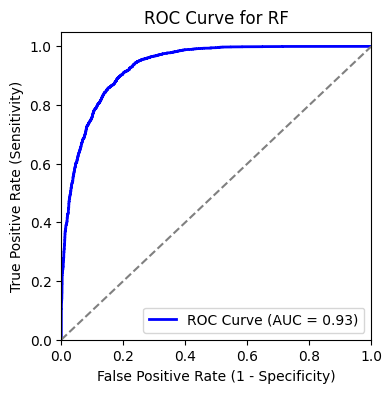

In [ ]:
# ROC and AUC for classification
y_pred_train_prob=final_rf.predict_proba(x_train)[:,1]
fpr, tpr, thresholds = roc_curve(y_train, y_pred_train_prob)
roc_auc = auc(fpr, tpr)  # Compute AUC - area under the curve
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for RF')
plt.legend(loc='lower right')
# plt.grid()
plt.show()

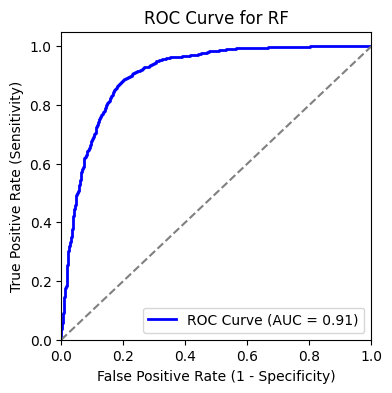

In [ ]:
# ROC and AUC for classification
y_pred_test_prob=final_rf.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob)
roc_auc = auc(fpr, tpr)  # Compute AUC - area under the curve
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for RF')
plt.legend(loc='lower right')
# plt.grid()
plt.show()

In [ ]:
# saving as joblib file into local and reading
from joblib import dump, load
dump(final_rf, "final_rf.joblib")

['final_rf.joblib']